Saving photo-1623018697148-8350cf18e64e.avif to photo-1623018697148-8350cf18e64e.avif
Image shape: (1024, 768)


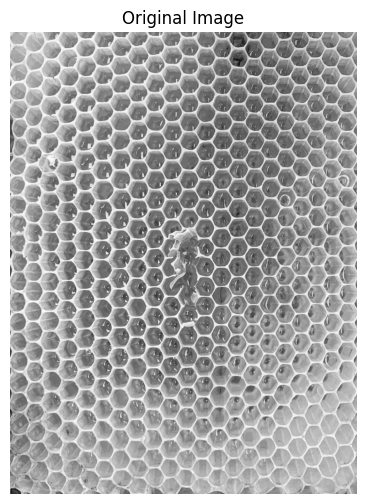

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
from PIL import Image
from google.colab import files

# Upload image
uploaded = files.upload()

filename = list(uploaded.keys())[0]

# Read image and convert to grayscale
img = Image.open(filename).convert('L')

# Resize so the long axis is at most 1024 pixels
max_size = 1024

scale = min(1.0, max_size / max(img.size))
new_size = (
    int(img.size[0] * scale),
    int(img.size[1] * scale)
)

img = img.resize(new_size)

# Convert to floating-point array
image = np.asarray(img, dtype=np.float64)

print("Image shape:", image.shape)

plt.figure(figsize=(8, 6))
plt.imshow(image, cmap='gray')
plt.title("Original Image")
plt.axis("off")
plt.show()

In [2]:
def fft1d(x):
    """
    1D Fast Fourier Transform using radix-2 Cooley-Tukey.
    Input length must be a power of 2.
    """

    x = np.asarray(x, dtype=complex)
    N = len(x)

    # Base case
    if N == 1:
        return x.copy()

    # Check power of 2
    if N & (N - 1):
        raise ValueError("Length of input must be a power of 2")

    # FFT of even and odd elements
    X_even = fft1d(x[::2])
    X_odd = fft1d(x[1::2])

    # Twiddle factors
    k = np.arange(N // 2)

    W = np.exp(-2j * np.pi * k / N)

    # Combine
    X = np.zeros(N, dtype=complex)

    X[:N//2] = X_even + W * X_odd
    X[N//2:] = X_even - W * X_odd

    return X

In [3]:
def ifft1d(X):
    """
    1D inverse FFT using the FFT implementation above.
    """

    X = np.asarray(X, dtype=complex)
    N = len(X)

    return np.conj(fft1d(np.conj(X))) / N

In [5]:
def fft2d(image):
    """
    2D FFT implemented using the 1D FFT.
    """

    image = np.asarray(image, dtype=complex)

    rows, cols = image.shape

    # FFT along rows
    temp = np.zeros((rows, cols), dtype=complex)

    for i in range(rows):
        temp[i, :] = fft1d(image[i, :])

    # FFT along columns
    result = np.zeros((rows, cols), dtype=complex)

    for j in range(cols):
        result[:, j] = fft1d(temp[:, j])

    return result

In [6]:
def ifft2d(F):
    """
    2D inverse FFT implemented using the 1D inverse FFT.
    """

    F = np.asarray(F, dtype=complex)

    rows, cols = F.shape

    # IFFT along rows
    temp = np.zeros((rows, cols), dtype=complex)

    for i in range(rows):
        temp[i, :] = ifft1d(F[i, :])

    # IFFT along columns
    result = np.zeros((rows, cols), dtype=complex)

    for j in range(cols):
        result[:, j] = ifft1d(temp[:, j])

    return result

In [8]:
def next_power_of_two(n):
    return 1 if n == 1 else 2 ** int(np.ceil(np.log2(n)))


def pad_to_power_of_two(image):
    rows, cols = image.shape

    new_rows = next_power_of_two(rows)
    new_cols = next_power_of_two(cols)

    padded = np.zeros((new_rows, new_cols), dtype=float)

    padded[:rows, :cols] = image

    return padded
padded_image = pad_to_power_of_two(image)

print("Original shape:", image.shape)
print("Padded shape:", padded_image.shape)

Original shape: (1024, 768)
Padded shape: (1024, 1024)


In [9]:
F = fft2d(padded_image)

reconstructed = ifft2d(F)

reconstructed = np.real(reconstructed)

error = np.max(np.abs(padded_image - reconstructed))

print("Maximum reconstruction error:", error)

Maximum reconstruction error: 1.1368683772161603e-13


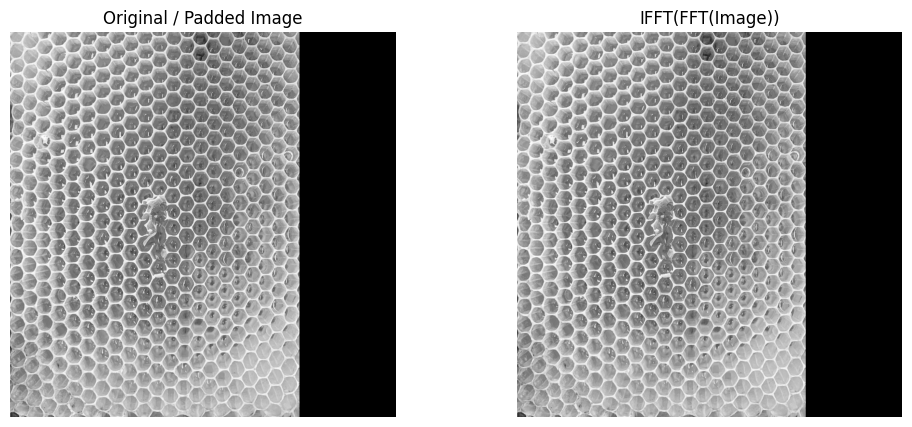

In [10]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(padded_image, cmap='gray')
plt.title("Original / Padded Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(reconstructed, cmap='gray')
plt.title("IFFT(FFT(Image))")
plt.axis("off")

plt.show()

In [13]:
def gaussian_kernel(size, sigma=None):
    """
    Create a 2D Gaussian blur kernel.
    """

    if sigma is None:
        sigma = size / 6.0

    ax = np.arange(-(size // 2), size // 2 + 1)

    xx, yy = np.meshgrid(ax, ax)

    kernel = np.exp(-(xx**2 + yy**2) / (2 * sigma**2))

    # Normalize so that kernel sums to 1
    kernel /= np.sum(kernel)

    return kernel


In [14]:
def spatial_convolution(image, kernel):
    """
    2D convolution implemented directly using image arrays.
    Zero padding is used at the boundaries.
    """

    image = np.asarray(image, dtype=float)
    kernel = np.asarray(kernel, dtype=float)

    kh, kw = kernel.shape

    pad_h = kh // 2
    pad_w = kw // 2

    padded = np.pad(
        image,
        ((pad_h, pad_h), (pad_w, pad_w)),
        mode='constant'
    )

    # Flip kernel for true convolution
    kernel_flipped = np.flipud(np.fliplr(kernel))

    output = np.zeros_like(image)

    for i in range(image.shape[0]):
        for j in range(image.shape[1]):

            region = padded[
                i:i+kh,
                j:j+kw
            ]

            output[i, j] = np.sum(region * kernel_flipped)

    return output

In [15]:
def prepare_kernel(kernel, shape):
    """
    Place the kernel in the top-left corner of an array
    and circularly shift it so that its center is at (0,0).
    """

    kh, kw = kernel.shape

    padded_kernel = np.zeros(shape, dtype=float)

    padded_kernel[:kh, :kw] = kernel

    # Move kernel center to (0,0)
    padded_kernel = np.roll(
        padded_kernel,
        -kh // 2,
        axis=0
    )

    padded_kernel = np.roll(
        padded_kernel,
        -kw // 2,
        axis=1
    )

    return padded_kernel

In [16]:
def frequency_convolution(image, kernel):
    """
    Perform convolution using our own FFT implementation.
    """

    image_padded = pad_to_power_of_two(image)

    kernel_padded = prepare_kernel(
        kernel,
        image_padded.shape
    )

    # FFT of image
    F = fft2d(image_padded)

    # FFT of kernel
    H = fft2d(kernel_padded)

    # Multiply in frequency domain
    G = F * H

    # Inverse FFT
    result = ifft2d(G)

    result = np.real(result)

    # Crop back to original size
    result = result[:image.shape[0], :image.shape[1]]

    return result, F, H, G

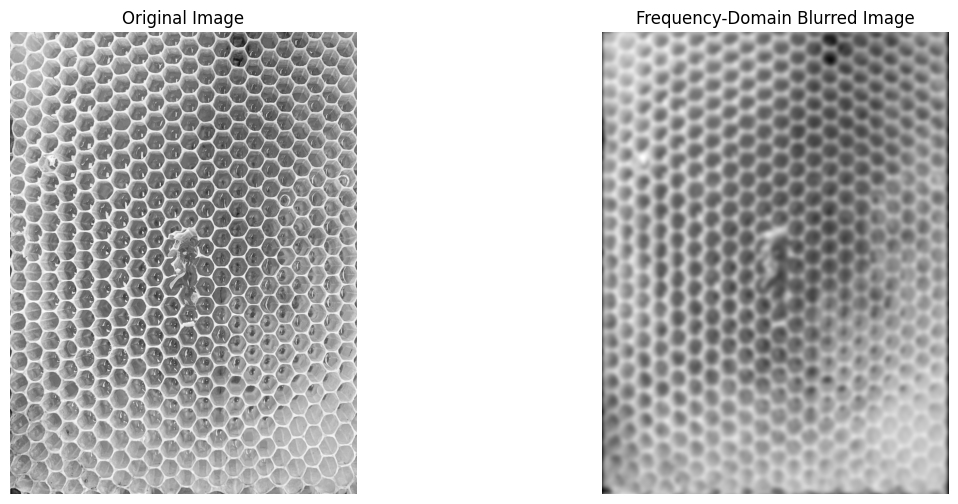

In [17]:
kernel_size = 31

kernel = gaussian_kernel(kernel_size)

blurred, F, H, G = frequency_convolution(
    image,
    kernel
)

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(blurred, cmap='gray')
plt.title("Frequency-Domain Blurred Image")
plt.axis("off")

plt.show()

In [18]:
def spectrum(F):
    return np.log1p(np.abs(np.fft.fftshift(F)))

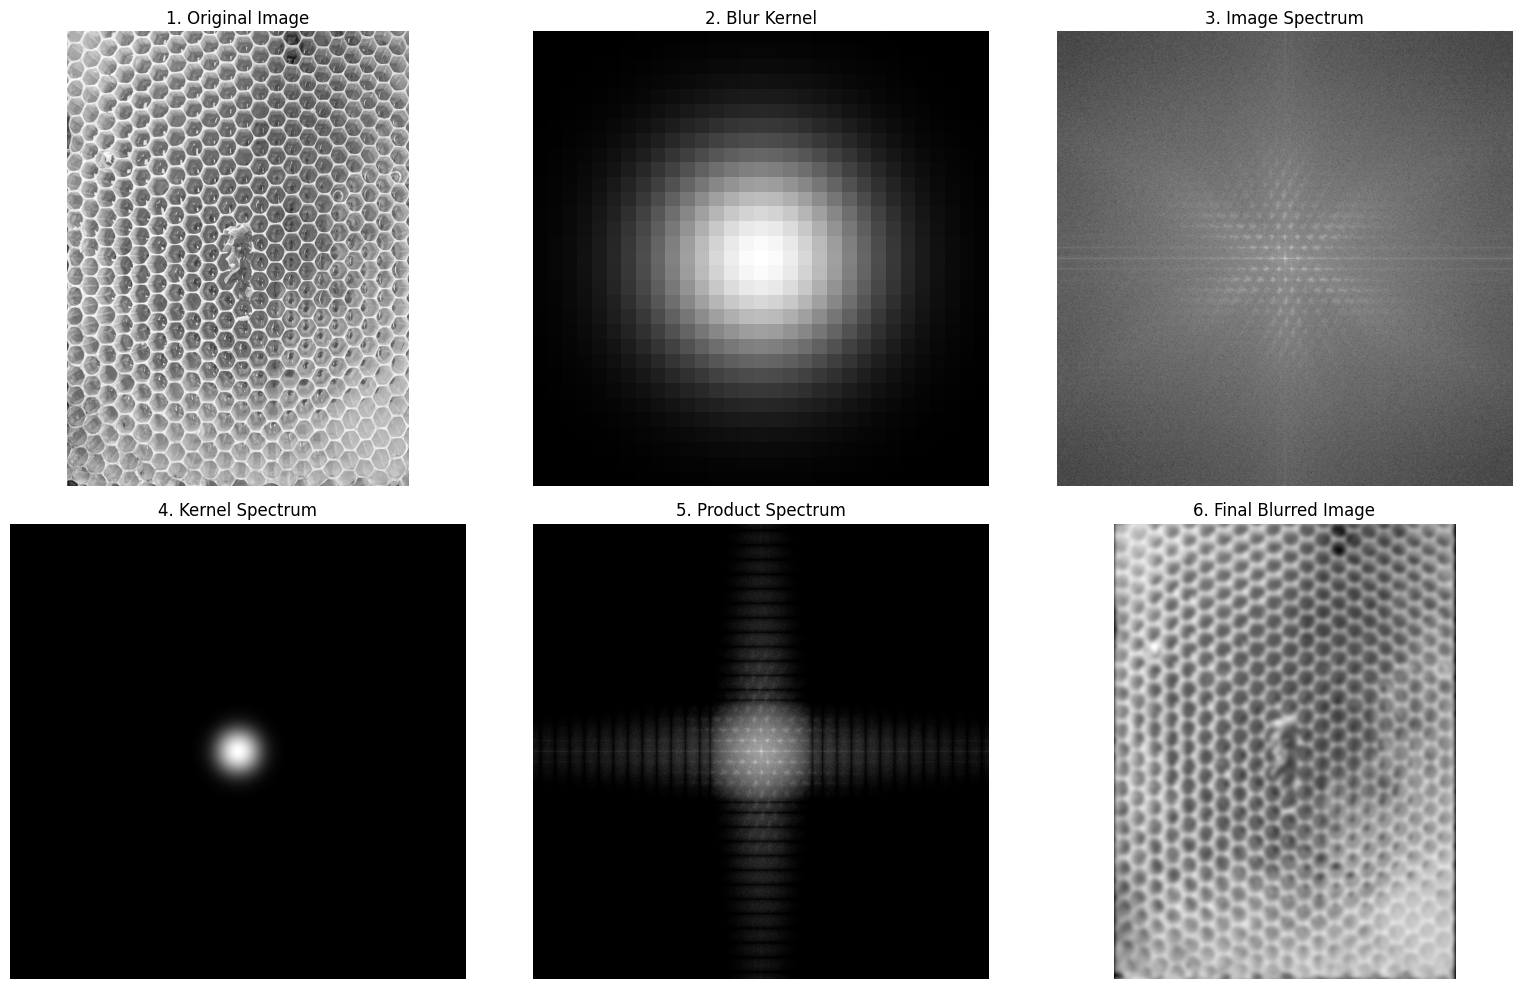

In [19]:
plt.figure(figsize=(16, 10))

plt.subplot(2, 3, 1)
plt.imshow(image, cmap='gray')
plt.title("1. Original Image")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(kernel, cmap='gray')
plt.title("2. Blur Kernel")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(spectrum(F), cmap='gray')
plt.title("3. Image Spectrum")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(spectrum(H), cmap='gray')
plt.title("4. Kernel Spectrum")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(spectrum(G), cmap='gray')
plt.title("5. Product Spectrum")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(blurred, cmap='gray')
plt.title("6. Final Blurred Image")
plt.axis("off")

plt.tight_layout()
plt.show()

In [20]:
# Use a smaller image for timing
timing_size = 256

timing_image = Image.open(filename).convert('L')

scale = min(
    1.0,
    timing_size / max(timing_image.size)
)

timing_image = timing_image.resize(
    (
        int(timing_image.size[0] * scale),
        int(timing_image.size[1] * scale)
    )
)

timing_image = np.asarray(
    timing_image,
    dtype=np.float64
)

print("Timing image shape:", timing_image.shape)

Timing image shape: (256, 192)


In [21]:
kernel_sizes = [3, 5, 9, 15, 25, 35, 51, 71]

spatial_times = []
frequency_times = []

for size in kernel_sizes:

    print("Kernel size:", size)

    kernel = gaussian_kernel(size)

    # -----------------------
    # Spatial filtering
    # -----------------------
    start = time.perf_counter()

    spatial_convolution(
        timing_image,
        kernel
    )

    end = time.perf_counter()

    spatial_time = end - start

    spatial_times.append(spatial_time)

    # -----------------------
    # Frequency filtering
    # -----------------------
    start = time.perf_counter()

    frequency_convolution(
        timing_image,
        kernel
    )

    end = time.perf_counter()

    frequency_time = end - start

    frequency_times.append(frequency_time)

    print(
        f"Spatial: {spatial_time:.4f}s | "
        f"Frequency: {frequency_time:.4f}s"
    )

Kernel size: 3
Spatial: 0.3363s | Frequency: 4.6193s
Kernel size: 5
Spatial: 0.3256s | Frequency: 5.9704s
Kernel size: 9
Spatial: 0.3338s | Frequency: 4.9023s
Kernel size: 15
Spatial: 0.3750s | Frequency: 5.3530s
Kernel size: 25
Spatial: 0.7038s | Frequency: 4.8576s
Kernel size: 35
Spatial: 0.5047s | Frequency: 4.5119s
Kernel size: 51
Spatial: 0.5953s | Frequency: 6.0103s
Kernel size: 71
Spatial: 0.7725s | Frequency: 4.5518s


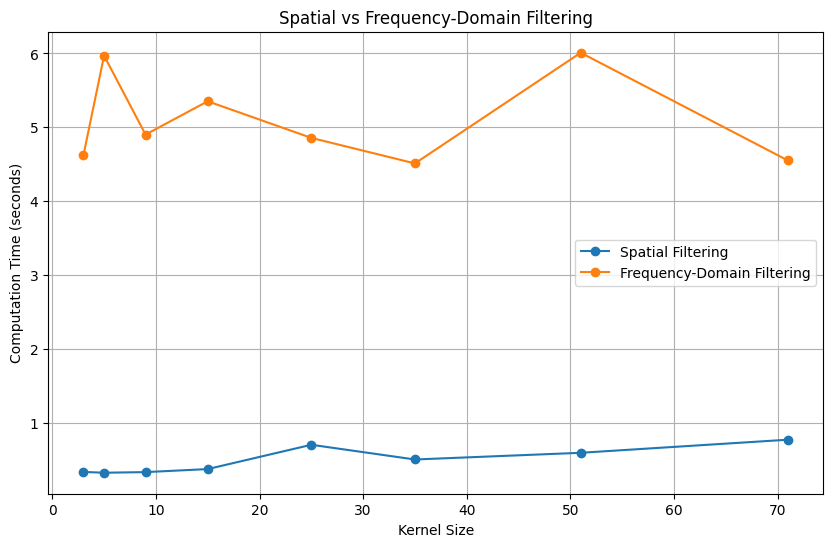

In [22]:
plt.figure(figsize=(10, 6))

plt.plot(
    kernel_sizes,
    spatial_times,
    marker='o',
    label='Spatial Filtering'
)

plt.plot(
    kernel_sizes,
    frequency_times,
    marker='o',
    label='Frequency-Domain Filtering'
)

plt.xlabel("Kernel Size")
plt.ylabel("Computation Time (seconds)")
plt.title("Spatial vs Frequency-Domain Filtering")
plt.legend()
plt.grid(True)

plt.show()

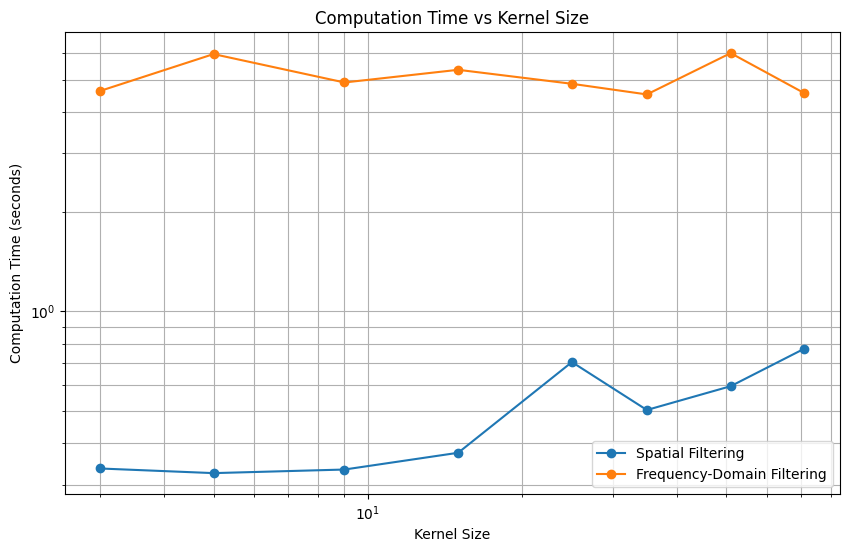

In [23]:
plt.figure(figsize=(10, 6))

plt.loglog(
    kernel_sizes,
    spatial_times,
    marker='o',
    label='Spatial Filtering'
)

plt.loglog(
    kernel_sizes,
    frequency_times,
    marker='o',
    label='Frequency-Domain Filtering'
)

plt.xlabel("Kernel Size")
plt.ylabel("Computation Time (seconds)")
plt.title("Computation Time vs Kernel Size")
plt.legend()
plt.grid(True, which="both")

plt.show()